In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score) 

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)

y = data.target

print("Dataset Shape:", X.shape)
print("\nTarget Classes:")
print(data.target_names)

print("\nFirst 5 rows:")
display(X.head())

Dataset Shape: (569, 30)

Target Classes:
['malignant' 'benign']

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [5]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Logistic Regression training completed.")

Logistic Regression training completed.


Confusion Matrix:
[[41  1]
 [ 1 71]]


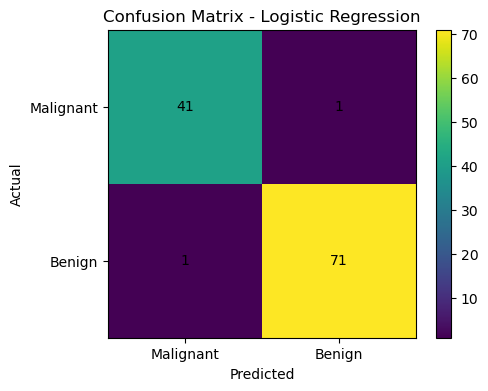

In [6]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0, 1], ["Malignant", "Benign"])
plt.yticks([0, 1], ["Malignant", "Benign"])
plt.show()

In [7]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [8]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1-Score : 0.9861111111111112


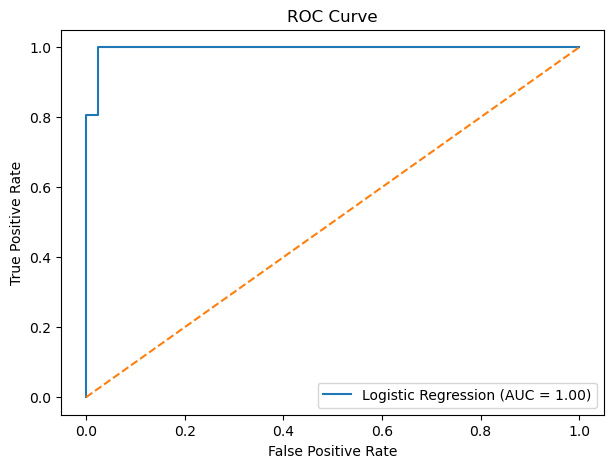

AUC Score: 0.9953703703703703


In [9]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", auc_score)

In [10]:
class_weight="balanced"
model_balanced = LogisticRegression(class_weight="balanced", max_iter=1000)

model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)

print("Balanced Logistic Regression")
print(classification_report(y_test, y_pred_balanced, target_names=data.target_names))
baseline_results = {"Accuracy": accuracy_score(y_test, y_pred), "Precision": precision_score(y_test, y_pred), "Recall": recall_score(y_test, y_pred), "F1-Score": f1_score(y_test, y_pred)}

balanced_results = {"Accuracy": accuracy_score(y_test, y_pred_balanced), "Precision": precision_score(y_test, y_pred_balanced), "Recall": recall_score(y_test, y_pred_balanced), "F1-Score": f1_score(y_test, y_pred_balanced)}

comparison = pd.DataFrame([baseline_results, balanced_results], index=["Baseline Logistic Regression", "Balanced Logistic Regression"])

display(comparison)

Balanced Logistic Regression
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



,Accuracy,Precision,Recall,F1-Score
Baseline Logistic Regression,0.982456,0.986111,0.986111,0.986111
Balanced Logistic Regression,0.956140,0.985507,0.944444,0.964539


In [11]:
tree = DecisionTreeClassifier(
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("Decision Tree Classification Report:")
print(classification_report(
    y_test,
    y_pred_tree,
    target_names=data.target_names
))

Decision Tree Classification Report:
              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



In [12]:
comparison_models = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Decision Tree"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_balanced),
        accuracy_score(y_test, y_pred_tree)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_balanced),
        precision_score(y_test, y_pred_tree)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_balanced),
        recall_score(y_test, y_pred_tree)
    ],
    
    "F1-Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_balanced),
        f1_score(y_test, y_pred_tree)
    ]
})

display(comparison_models)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,Balanced Logistic Regression,0.956140,0.985507,0.944444,0.964539
2,Decision Tree,0.912281,0.955882,0.902778,0.928571


In [13]:
y_prob_tree = tree.predict_proba(X_test)[:, 1]
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
auc_tree = roc_auc_score( y_test, y_prob_tree)
print("Decision Tree AUC:", auc_tree)

Decision Tree AUC: 0.9156746031746031


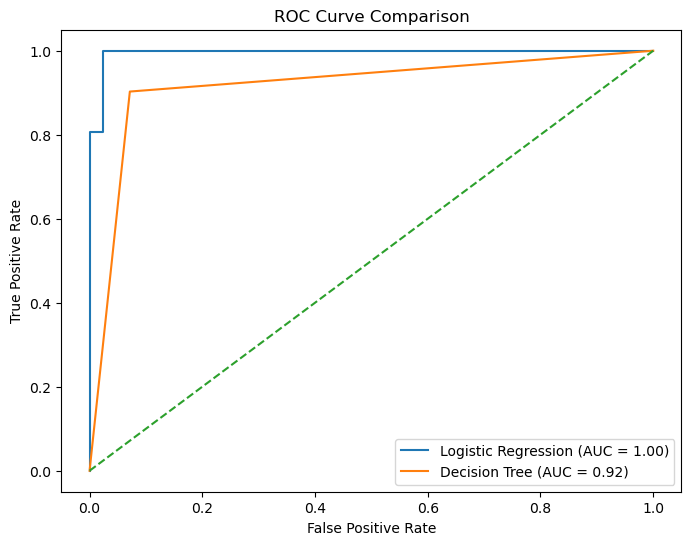

In [14]:
y_prob_logistic = model.predict_proba(X_test_scaled)[:, 1]

fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    y_prob_logistic
)

auc_logistic = roc_auc_score(
    y_test,
    y_prob_logistic
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {auc_logistic:.2f})"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {auc_tree:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [15]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Decision Tree"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_balanced),
        accuracy_score(y_test, y_pred_tree)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_balanced),
        precision_score(y_test, y_pred_tree)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_balanced),
        recall_score(y_test, y_pred_tree)
    ],
    
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_balanced),
        f1_score(y_test, y_pred_tree)
    ],
    
    "AUC": [
        auc_logistic,
        roc_auc_score(
            y_test,
            model_balanced.predict_proba(X_test_scaled)[:, 1]
        ),
        auc_tree
    ]
})

display(final_comparison)

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370
1,Balanced Logistic Regression,0.956140,0.985507,0.944444,0.964539,0.995370
2,Decision Tree,0.912281,0.955882,0.902778,0.928571,0.915675


In [16]:
print("""
FINAL CONCLUSION

Three classification models were evaluated:

1. Logistic Regression
2. Balanced Logistic Regression
3. Decision Tree Classifier

The models were evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

For medical diagnosis, accuracy alone is not sufficient.
Recall is particularly important because false negatives can
represent patients whose disease is not detected.

The final model should therefore be selected based on the
appropriate business/medical objective rather than accuracy alone.
""")


FINAL CONCLUSION

Three classification models were evaluated:

1. Logistic Regression
2. Balanced Logistic Regression
3. Decision Tree Classifier

The models were evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

For medical diagnosis, accuracy alone is not sufficient.
Recall is particularly important because false negatives can
represent patients whose disease is not detected.

The final model should therefore be selected based on the
appropriate business/medical objective rather than accuracy alone.

